In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/dataset/global_pharmacy_sales_2020_2025_daily_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.size

2491860

In [ ]:
df.shape

(177990, 14)

In [ ]:
df.head()
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177990 entries, 0 to 177989
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   date                   177990 non-null  object 
 1   year                   177990 non-null  int64  
 2   month                  177990 non-null  int64  
 3   day                    177990 non-null  int64  
 4   region                 177990 non-null  object 
 5   country                177990 non-null  object 
 6   category               177990 non-null  object 
 7   medicine               177990 non-null  object 
 8   age_group              177990 non-null  object 
 9   units_sold             177990 non-null  int64  
 10  unit_price             177990 non-null  float64
 11  stock_level            177990 non-null  int64  
 12  expiry_days_remaining  177990 non-null  int64  
 13  covid_flag             177990 non-null  int64  
dtypes: float64(1), int64(7), object(6)
m

Index(['date', 'year', 'month', 'day', 'region', 'country', 'category',
       'medicine', 'age_group', 'units_sold', 'unit_price', 'stock_level',
       'expiry_days_remaining', 'covid_flag'],
      dtype='object')

In [ ]:
df.describe()

,year,month,day,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag
count,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000
mean,2022.499702,6.521754,15.730457,447.913849,52.554729,4552.991780,374.038109,0.333519
std,1.708113,3.448703,8.801170,338.924528,27.421909,346.608511,199.759193,0.471471
min,2020.000000,1.000000,1.000000,31.000000,5.000000,0.000000,30.000000,0.000000
25%,2021.000000,4.000000,8.000000,284.000000,28.770000,4443.000000,200.000000,0.000000
50%,2023.000000,7.000000,16.000000,387.000000,52.600000,4598.000000,374.000000,0.000000
75%,2024.000000,10.000000,23.000000,529.000000,76.310000,4735.000000,547.000000,1.000000
max,2025.000000,12.000000,31.000000,8704.000000,100.000000,5124.000000,720.000000,1.000000


In [ ]:
df.isnull().sum()

,0
date,0
year,0
month,0
day,0
region,0
country,0
category,0
medicine,0
age_group,0
units_sold,0


In [ ]:
df.duplicated().sum()

np.int64(2630)

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df.dtypes

,0
date,datetime64[ns]
year,int64
month,int64
day,int64
region,object
country,object
category,object
medicine,object
age_group,object
units_sold,int64


In [ ]:
df.isnull().sum()

,0
date,0
year,0
month,0
day,0
region,0
country,0
category,0
medicine,0
age_group,0
units_sold,0


In [ ]:
df.drop_duplicates(inplace=True)

In [69]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
cols = ['region','country','category','medicine','age_group']
for col in cols:
    df[col] = encoder.fit_transform(df[col])

**Exploratory Data Analysis**

In [71]:
df.describe()

,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag,dayofweek,quarter,week
count,175360,175360.000000,175360.000000,175360.000000,175360.000000,175360.000000,175360.000000,175360.00000,175360.000000,175360.000000,175360.000000,175360.000000,175360.000000,175360.000000,175360.000000,175360.000000,175360.0
mean,2022-12-31 12:00:00.000000256,2022.499544,6.521898,15.732664,3.500000,8.970193,2.000000,4.50000,2.003878,447.847765,52.551273,4553.132619,374.138487,0.333485,2.999544,2.508212,26.572993
min,2020-01-01 00:00:00,2020.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,31.000000,5.000000,0.000000,30.000000,0.000000,0.000000,1.000000,1.0
25%,2021-07-01 18:00:00,2021.000000,4.000000,8.000000,1.750000,4.000000,1.000000,2.00000,1.000000,284.000000,28.780000,4443.000000,200.000000,0.000000,1.000000,2.000000,14.0
50%,2022-12-31 12:00:00,2022.500000,7.000000,16.000000,3.500000,10.000000,2.000000,4.50000,2.000000,387.000000,52.610000,4598.000000,374.000000,0.000000,3.000000,3.000000,27.0
75%,2024-07-01 06:00:00,2024.000000,10.000000,23.000000,5.250000,14.000000,3.000000,7.00000,3.000000,528.000000,76.290000,4735.000000,547.000000,1.000000,5.000000,4.000000,40.0
max,2025-12-31 00:00:00,2025.000000,12.000000,31.000000,7.000000,18.000000,4.000000,9.00000,4.000000,8704.000000,100.000000,5124.000000,720.000000,1.000000,6.000000,4.000000,53.0
std,NaN,1.708186,3.448996,8.801395,2.291294,5.603037,1.414218,2.87229,1.415430,338.887291,27.416471,346.422890,199.771560,0.471460,1.999663,1.117191,15.065295


Correlation

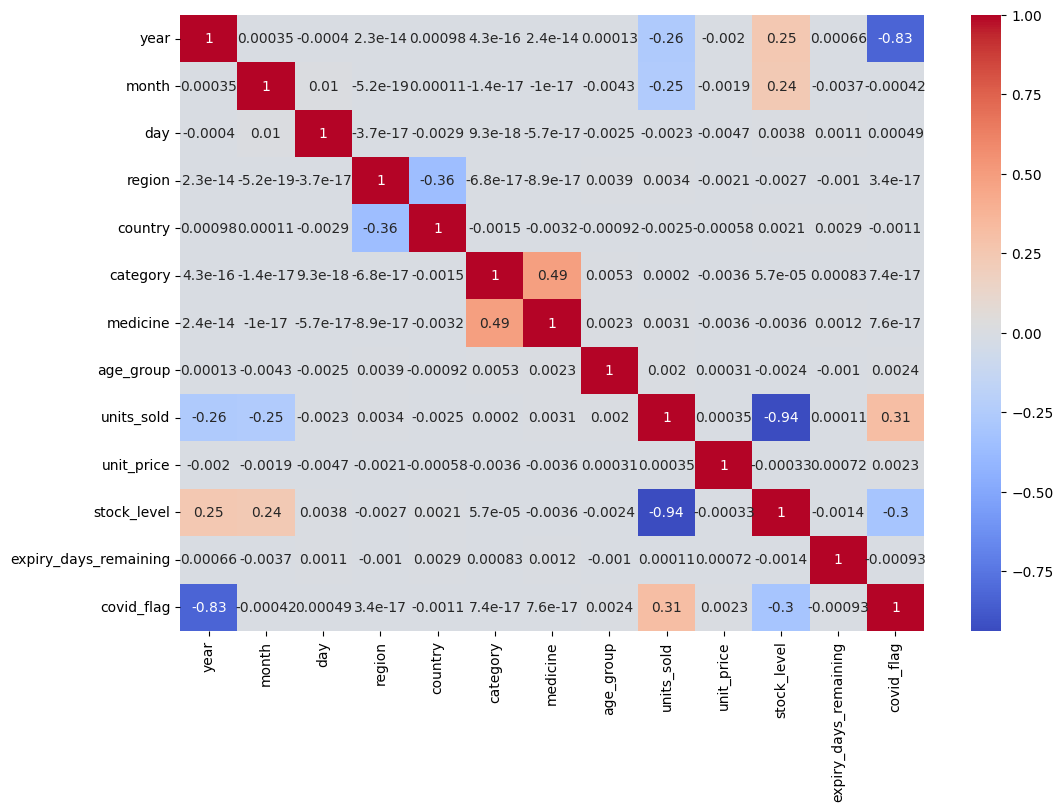

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

Sales Distribution

<Axes: xlabel='units_sold', ylabel='Count'>

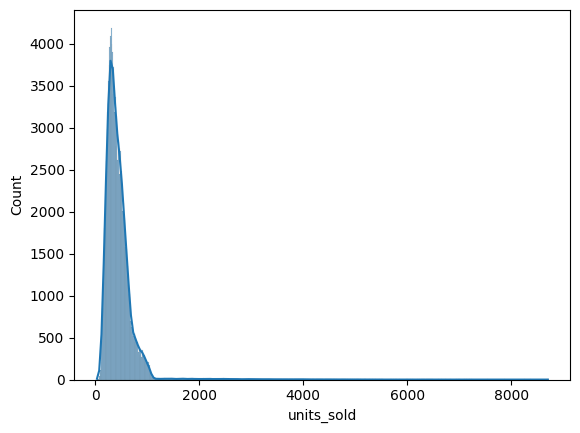

In [ ]:
sns.histplot(df['units_sold'], kde=True)

Unit Price Distribution

<Axes: xlabel='unit_price'>

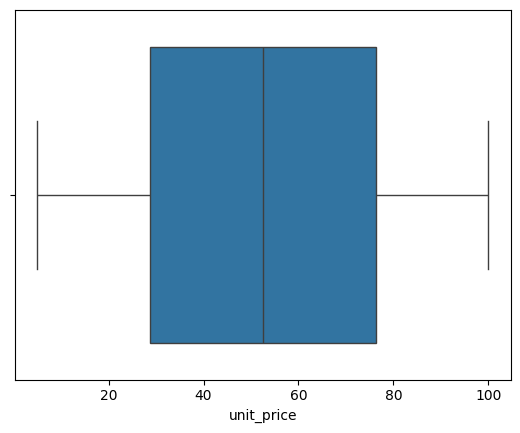

In [ ]:
sns.boxplot(x=df['unit_price'])

Sales by Category

<Axes: xlabel='category', ylabel='units_sold'>

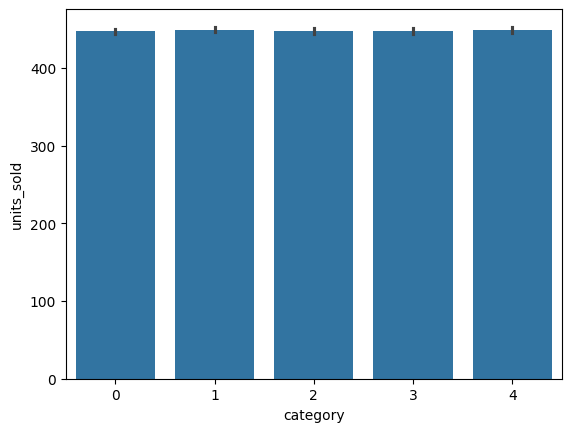

In [ ]:
sns.barplot(
    x='category',
    y='units_sold',
    data=df)

Sales by Region

<Axes: xlabel='region', ylabel='units_sold'>

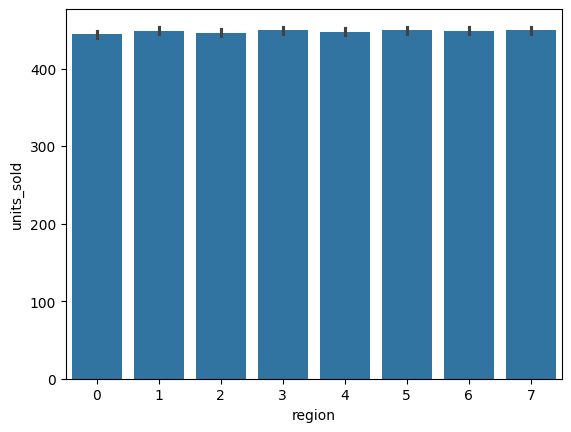

In [ ]:
sns.barplot(
    x='region',
    y='units_sold',
    data=df)

Sales by Country

<Axes: xlabel='country'>

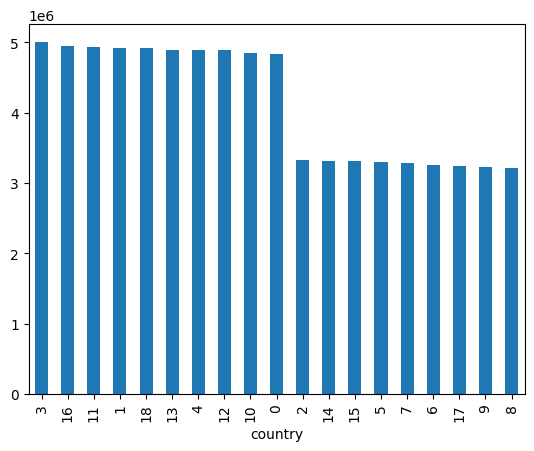

In [ ]:
top = df.groupby('country')['units_sold'].sum().sort_values(ascending=False)
top.plot(kind='bar')

Monthly Sales Trend

<Axes: xlabel='month'>

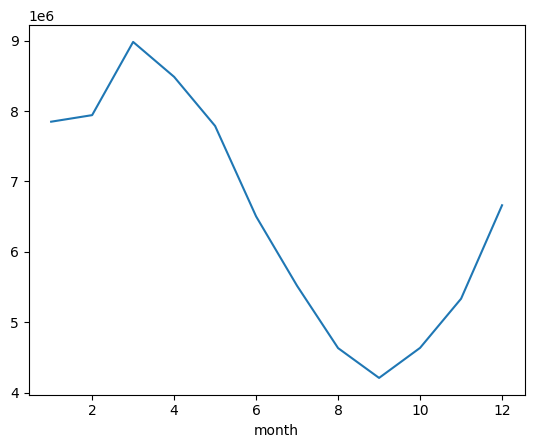

In [ ]:
monthly = df.groupby('month')['units_sold'].sum()
monthly.plot()

Covid vs Non-Covid Sales

<Axes: xlabel='covid_flag', ylabel='units_sold'>

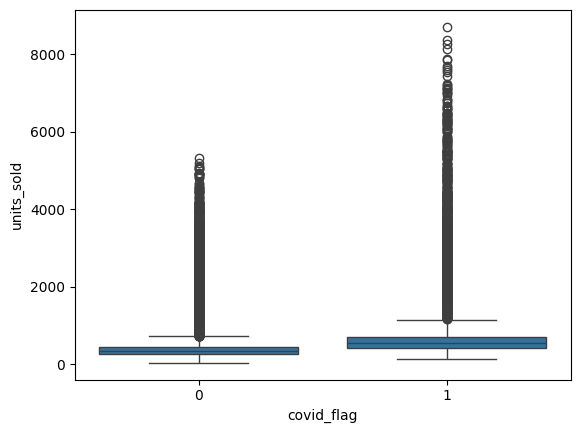

In [ ]:
sns.boxplot(
    x='covid_flag',
    y='units_sold',
    data=df)

Stock vs Sales

<Axes: xlabel='stock_level', ylabel='units_sold'>

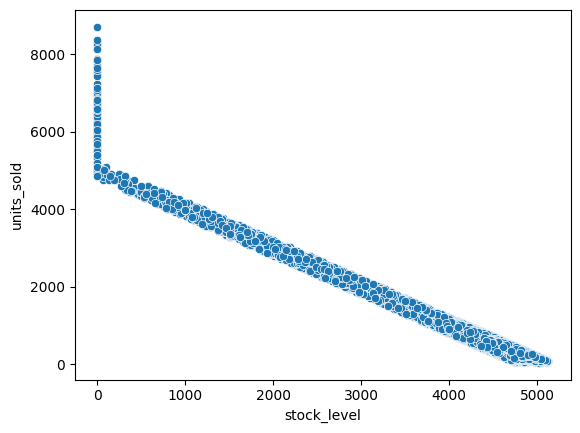

In [ ]:
sns.scatterplot(
    x='stock_level',
    y='units_sold',
    data=df)

Expiry vs Sales

<Axes: xlabel='expiry_days_remaining', ylabel='units_sold'>

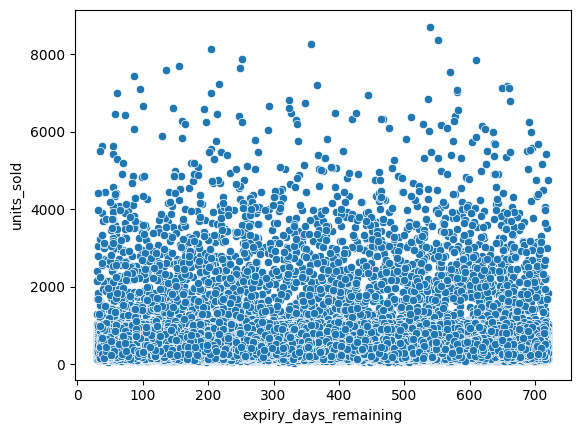

In [ ]:
sns.scatterplot(
    x='expiry_days_remaining',
    y='units_sold',
    data=df)

**Feature Engineering**

In [ ]:
df['dayofweek'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter
df['week'] = df['date'].dt.isocalendar().week

In [ ]:
y = df['units_sold']

In [ ]:
X = df.drop(['units_sold','date'], axis=1)

Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42)

# **Model Building**

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

Random Forest

In [66]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(
    n_estimators=200,
    random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

# **Model Evaluation**

In [67]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)
import numpy as np
pred = rf.predict(X_test)
print("MAE:",mean_absolute_error(y_test,pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))
print("R2:",r2_score(y_test,pred))

MAE: 65.15283887431569
RMSE: 84.83279145093755
R2: 0.9382579961345296


Feature Importance

In [68]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_})
importance.sort_values(
    by='Importance',
    ascending=False)

,Feature,Importance
9,stock_level,0.920757
1,month,0.013559
8,unit_price,0.008983
10,expiry_days_remaining,0.008820
0,year,0.008073
11,covid_flag,0.006478
2,day,0.005921
4,country,0.004816
14,week,0.004312
6,medicine,0.003627
